Multiclass_Segmentation_Classwise_Metrics_Analysis.ipynb

In [1]:
# Code cell
!pip install matplotlib pillow numpy torchvision --quiet

import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw
import urllib.request
from io import BytesIO
import time
import torchvision.transforms as T

plt.rcParams["figure.figsize"] = (10,5)


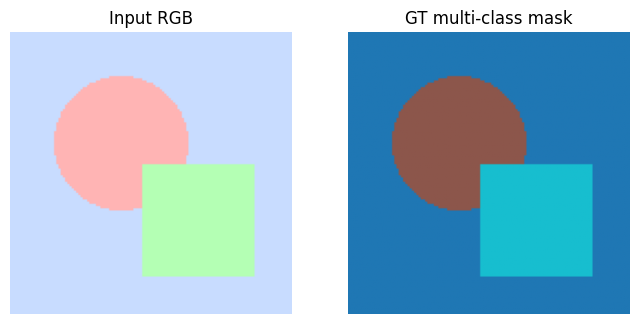

In [2]:
# Code cell: create synthetic image + multi-class mask (128x128)
H, W = 128, 128

# Create blank RGB image
img = Image.new("RGB", (W,H), (200, 220, 255))
draw = ImageDraw.Draw(img)
# draw two colored blobs for classes
draw.ellipse((20, 20, 80, 80), fill=(255,180,180))  # class 1 region (pink)
draw.rectangle((60, 60, 110, 110), fill=(180,255,180))  # class 2 region (green)

# Generate multi-class mask (0,1,2)
mask = Image.new("L", (W,H), 0)
md = ImageDraw.Draw(mask)
md.ellipse((20, 20, 80, 80), fill=1)  # class 1
md.rectangle((60, 60, 110, 110), fill=2)  # class 2
# Note: overlapping area will take later draw (rectangle -> class 2) so overlap belongs to class2

# Convert to numpy
image_np = np.array(img)
mask_np = np.array(mask).astype(np.int64)

# Visualize
fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(image_np); ax[0].set_title("Input RGB"); ax[0].axis("off")
ax[1].imshow(mask_np, cmap="tab10", vmin=0, vmax=2); ax[1].set_title("GT multi-class mask"); ax[1].axis("off")
plt.show()


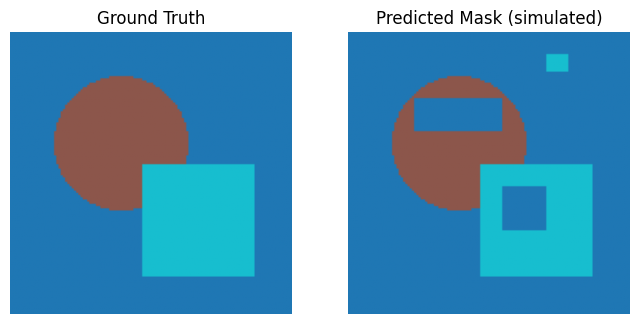

In [3]:
# Code cell
pred_mask = mask_np.copy()

# Simulate some errors:
# Remove some pixels from class 1 (false negatives)
pred_mask[30:45, 30:70][pred_mask[30:45, 30:70] == 1] = 0
# Add some noise as false positives for class 2
pred_mask[10:18, 90:100] = 2
# Slightly shrink class2 to create FN for class2
pred_mask[70:90, 70:90][pred_mask[70:90, 70:90] == 2] = 0

fig, ax = plt.subplots(1,2, figsize=(8,4))
ax[0].imshow(mask_np, cmap="tab10", vmin=0, vmax=2); ax[0].set_title("Ground Truth"); ax[0].axis("off")
ax[1].imshow(pred_mask, cmap="tab10", vmin=0, vmax=2); ax[1].set_title("Predicted Mask (simulated)"); ax[1].axis("off")
plt.show()


In [4]:
# Code cell: metric functions
def compute_confusion_per_class(gt, pred, num_classes):
    """
    Returns arrays TP, FP, FN, TN for each class (length=num_classes)
    gt, pred: 2D numpy arrays with integer labels 0..num_classes-1
    """
    TP = np.zeros(num_classes, dtype=np.int64)
    FP = np.zeros(num_classes, dtype=np.int64)
    FN = np.zeros(num_classes, dtype=np.int64)
    TN = np.zeros(num_classes, dtype=np.int64)
    total = gt.size

    for c in range(num_classes):
        gt_c = (gt == c)
        pred_c = (pred == c)
        TP[c] = np.logical_and(gt_c, pred_c).sum()
        FP[c] = np.logical_and(~gt_c, pred_c).sum()
        FN[c] = np.logical_and(gt_c, ~pred_c).sum()
        TN[c] = total - (TP[c] + FP[c] + FN[c])
    return TP, FP, FN, TN

def per_class_metrics(gt, pred, num_classes, eps=1e-8):
    TP, FP, FN, TN = compute_confusion_per_class(gt, pred, num_classes)
    iou = TP / (TP + FP + FN + eps)
    dice = (2 * TP) / (2 * TP + FP + FN + eps)
    pixel_acc = TP / (TP + FN + eps)  # recall-like per-class accuracy
    return {
        "TP": TP, "FP": FP, "FN": FN, "TN": TN,
        "IoU": iou, "Dice": dice, "Pixel_Acc": pixel_acc
    }


In [5]:
# Code cell
num_classes = int(max(mask_np.max(), pred_mask.max())) + 1
metrics = per_class_metrics(mask_np, pred_mask, num_classes)

# Print per-class results
for c in range(num_classes):
    print(f"Class {c}: TP={metrics['TP'][c]}, FP={metrics['FP'][c]}, FN={metrics['FN'][c]}")
    print(f"  IoU = {metrics['IoU'][c]:.4f}, Dice = {metrics['Dice'][c]:.4f}, PixelAcc = {metrics['Pixel_Acc'][c]:.4f}")

# Compute mean IoU and mean Dice across classes
mean_iou = metrics['IoU'].mean()
mean_dice = metrics['Dice'].mean()
print("\nMean IoU:", round(float(mean_iou),4))
print("Mean Dice:", round(float(mean_dice),4))


Class 0: TP=11040, FP=1000, FN=80
  IoU = 0.9109, Dice = 0.9534, PixelAcc = 0.9928
Class 1: TP=2063, FP=0, FN=600
  IoU = 0.7747, Dice = 0.8730, PixelAcc = 0.7747
Class 2: TP=2201, FP=80, FN=400
  IoU = 0.8210, Dice = 0.9017, PixelAcc = 0.8462

Mean IoU: 0.8355
Mean Dice: 0.9094


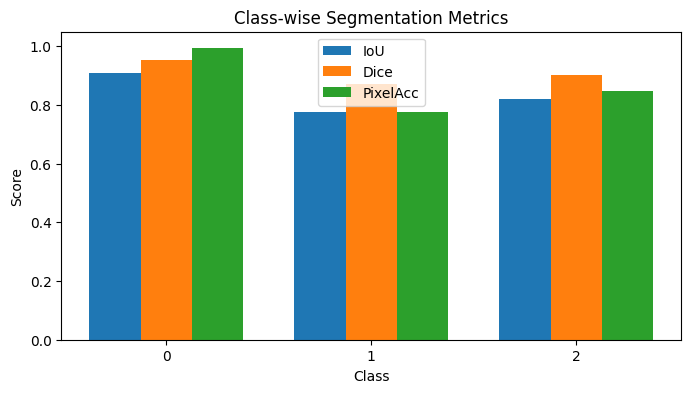

In [6]:
# Code cell
classes = list(range(num_classes))
iou_scores = metrics['IoU']
dice_scores = metrics['Dice']
pixacc_scores = metrics['Pixel_Acc']

x = np.arange(len(classes))
width = 0.25

fig, ax = plt.subplots(figsize=(8,4))
ax.bar(x - width, iou_scores, width, label='IoU')
ax.bar(x, dice_scores, width, label='Dice')
ax.bar(x + width, pixacc_scores, width, label='PixelAcc')

ax.set_xlabel("Class")
ax.set_ylabel("Score")
ax.set_title("Class-wise Segmentation Metrics")
ax.set_xticks(x)
ax.set_xticklabels([str(c) for c in classes])
ax.set_ylim(0,1.05)
ax.legend()
plt.show()


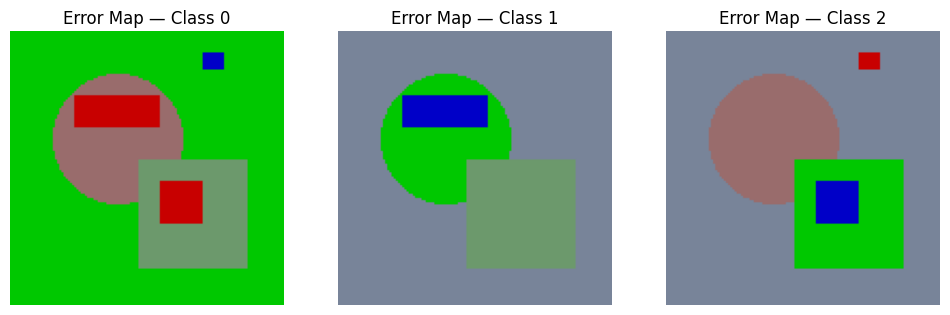

In [7]:
# Code cell
def error_map_overlay(image_np, gt, pred, cls):
    """
    Returns an RGB image visualizing TP (green), FP (red), FN (blue) for the chosen class.
    image_np: HxWx3 original image
    gt, pred: HxW integer masks
    cls: integer class index to visualize
    """
    H,W,_ = image_np.shape
    overlay = image_np.copy().astype(np.uint8)
    tp = np.logical_and(gt==cls, pred==cls)
    fp = np.logical_and(gt!=cls, pred==cls)
    fn = np.logical_and(gt==cls, pred!=cls)

    # Darken original image slightly
    overlay = (overlay * 0.6).astype(np.uint8)

    # Apply colors
    overlay[tp] = [0, 200, 0]    # green
    overlay[fp] = [200, 0, 0]    # red
    overlay[fn] = [0, 0, 200]    # blue

    return overlay

# Visualize for each class
selected_classes = classes  # visualize all; you can select subset e.g. [1,2]
fig, axs = plt.subplots(1, len(selected_classes), figsize=(4*len(selected_classes),4))
if len(selected_classes) == 1:
    axs = [axs]
for ax, c in zip(axs, selected_classes):
    emap = error_map_overlay(image_np, mask_np, pred_mask, c)
    ax.imshow(emap); ax.axis("off"); ax.set_title(f"Error Map — Class {c}")

plt.show()


In [8]:
# Code cell
class_sizes = np.array([(mask_np == c).sum() for c in classes]).astype(float)
total_pixels = class_sizes.sum()
weights = class_sizes / (total_pixels + 1e-8)

weighted_mean_iou = (metrics['IoU'] * weights).sum()
weighted_mean_dice = (metrics['Dice'] * weights).sum()

print("Weighted Mean IoU (by class-size):", weighted_mean_iou)
print("Weighted Mean Dice (by class-size):", weighted_mean_dice)

print("\nClass sizes:", class_sizes)


Weighted Mean IoU (by class-size): 0.8744770461828061
Weighted Mean Dice (by class-size): 0.932106466197522

Class sizes: [11120.  2663.  2601.]
